# 1. Ответы на теоретические вопросы

## i. What is leave-one-out? Provide limitations and strengths.

**Определение:**
Leave-One-Out Cross-Validation — предельный случай кросс-валидации, где $k = N$. Модель обучается на $N-1$ объектах и тестируется на одном. Итоговая метрика = среднее $N$ метрик:
$$\text{CV}_{(n)} = \frac{1}{N} \sum_{i=1}^{N} \text{Loss}\big(y_i, \hat{f}^{-i}(x_i)\big)$$

**Сильные стороны:**
- Почти несмещённая оценка — максимум данных идёт в обучение.
- Детерминированность: нет случайности в разбиении.
- Критично для малых выборок.

**Ограничения:**
- $O(N)$ обучений — неприменимо при большом $N$.
- Высокая дисперсия оценки (обучающие выборки почти идентичны).

---

## ii. Grid Search, Randomized Grid Search, Bayesian Optimization

**Grid Search:** перебирает **все** комбинации заданной сетки. Гарантирует оптимум в сетке, но экспоненциально дорог.

**Random Search:** случайно семплирует $M$ комбинаций. При том же бюджете покрывает больше пространства (теорема Бергстра–Бенжио).

**Bayesian (Optuna / TPE):** строит суррогатную вероятностную модель $f(\theta) \to \text{метрика}$, балансирует exploration vs exploitation через acquisition function (Expected Improvement). Сходится за меньше итераций, помнит историю.

---

## iii. Методы отбора признаков

**Классификация:**
- **Filter** — до обучения, статистика (Pearson, Chi2).
- **Embedded** — во время обучения (Lasso).
- **Wrapper** — перебор подмножеств (RFE, forward selection).
- **Post-hoc** — после обучения (Permutation, SHAP).

**Pearson:** матрица линейных корреляций. Удаляем признаки с $|r| \to 1$ (дублируют друг друга). Только линейные зависимости.

**Chi2:** для категориальных переменных. Большое $\chi^2$ → сильная зависимость с таргетом.

**Lasso:** L1-штраф $\lambda \sum|\beta_j|$ зануляет коэффициенты незначимых признаков точно в 0 (геометрически — ромб ограничения имеет вершины на осях координат).

**Permutation Importance:** перемешиваем значения признака $j$ → измеряем падение метрики → это его важность. Model-agnostic.

**SHAP:** Shapley values из теории кооперативных игр. $\phi_j$ = средний вклад признака $j$ по всем коалициям. Локально точен: $f(x) = \phi_0 + \sum_j \phi_j$.

# 2. Загрузка данных и создание признаков

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
warnings.filterwarnings('ignore')
from typing import List, Tuple, Optional

from sklearn.model_selection import cross_val_score, ParameterGrid, ParameterSampler
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    KFold, GroupKFold, StratifiedKFold,
    TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
import shap
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [ ]:
train = pd.read_json('data/train.json')
test = pd.read_json('data/test.json')

Train: (48379, 36), Test: (73255, 35)
Features: ['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace', 'bathrooms', 'bedrooms']


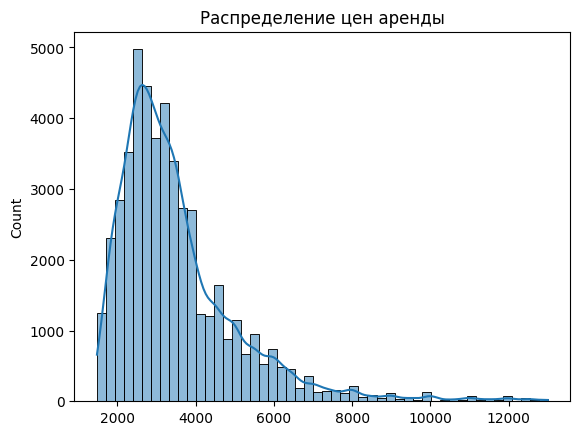

In [ ]:
lower_boundary = train['price'].quantile(0.01)
upper_boundary = train['price'].quantile(0.99)
train = train[train['price'].between(lower_boundary, upper_boundary)].copy()
test = test[test['price'].between(lower_boundary, upper_boundary)].copy()

for df in [train, test]:
    df['features_clean'] = (df['features'].astype(str)
                            .str.replace(r"[\[\]'\"\s]", '', regex=True)
                            )

target_features = [
    'Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman',
    'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War',
    'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet',
    'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace'
]

def has_feature(feature_str: str, feature_name: str) -> int:
    """Проверяет наличие удобства в строке описания (регистронезависимо)"""
    return int(feature_name.lower() in feature_str.lower())

for f in target_features:
    train[f] = train['features_clean'].apply(has_feature, feature_name=f)
    test[f] = test['features_clean'].apply(has_feature, feature_name=f)

feature_list = target_features + ['bathrooms', 'bedrooms']

X = train[feature_list].values.astype(float)
y = train['price'].values.astype(float)
X_test = test[feature_list].values.astype(float)

scaler_global = MinMaxScaler()
X_scaled = scaler_global.fit_transform(X)
X_test_scaled = scaler_global.transform(X_test)

print(f"Train: {train.shape}, Test: {test.shape}")
print(f"Features: {feature_list}")
sns.histplot(y, bins=50, kde=True)
plt.title('Распределение цен аренды')
plt.show()

# 3. Методы разбивки данных

In [ ]:
class DataSplitter:
    """Класс для различных стратегий разбиения данных."""

    def __init__(self, random_state: int = 42):
        self.random_state = random_state

    def _get_rng(self) -> np.random.Generator:
        """Локальный генератор — обеспечивает детерминизм при одинаковом random_state."""
        
        return np.random.default_rng(self.random_state)

    # 3.1 Случайный сплит на 2 части
    def train_test_split_random(self, X: np.ndarray, y: np.ndarray, test_size: float
                                ) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Случайное разбиение на train/test.
        test_size: доля тест-выборки (0 < test_size < 1).
        """
        if not 0 < test_size < 1:
            raise ValueError("test_size должен быть в (0, 1)")

        rng = self._get_rng()
        n = len(X)
        idx = rng.permutation(n)
        n_test = int(n * test_size)
        test_idx, train_idx = idx[:n_test], idx[n_test:]

        return X[train_idx], X[test_idx], y[train_idx], y[test_idx]

    # 3.2  Случайный сплит на 3 части
    def train_val_test_split_random(self, X: np.ndarray, y: np.ndarray, validation_size: float,
        test_size: float) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Случайное разбиение на train/val/test.
        """
        if not (0 < validation_size < 1 and 0 < test_size < 1):
            raise ValueError("Доли должны быть в (0, 1)")
        if validation_size + test_size >= 1:
            raise ValueError("Сумма validation_size + test_size должна быть < 1")

        rng = self._get_rng()
        n = len(X)
        idx = rng.permutation(n)
        n_test = int(n * test_size)
        n_val = int(n * validation_size)
        test_idx = idx[:n_test]
        val_idx = idx[n_test:n_test + n_val]
        train_idx = idx[n_test + n_val:]

        return (
            X[train_idx], X[val_idx], X[test_idx],
            y[train_idx], y[val_idx], y[test_idx]
        )

    # 3.3  Датовый сплит на 2 части
    def train_test_split_by_date(self, X: np.ndarray, y: np.ndarray, dates: pd.Series,
        date_split: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Разбивка по дате: до date_split -> train, с date_split -> test.
        """
        split_ts = pd.Timestamp(date_split)
        train_mask = pd.to_datetime(dates) < split_ts
        test_mask = ~train_mask

        return X[train_mask], X[test_mask], y[train_mask], y[test_mask]

    # 3.4  Датовый сплит на 3 части
    def train_val_test_split_by_date(self, X: np.ndarray, y: np.ndarray, dates: pd.Series,
        validation_date: str, test_date: str) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
        """Разбивка по двум датам: три непересекающихся интервала.
        max(train.date) < validation_date ≤ max(val.date) < test_date.
        """
        val_ts = pd.Timestamp(validation_date)
        test_ts = pd.Timestamp(test_date)
        d = pd.to_datetime(dates)
        train_mask = d < val_ts
        val_mask = (d >= val_ts) & (d < test_ts)
        test_mask = d >= test_ts

        return (
            X[train_mask], X[val_mask], X[test_mask],
            y[train_mask], y[val_mask], y[test_mask]
        )

    def make_deterministic(self, seed: int = 42):
        """Устанавливает seed — при одинаковом seed результат воспроизводим."""
        self.random_state = seed

In [ ]:
# Применяем все методы сплита
splitter = DataSplitter(random_state=42)
dates_series = pd.to_datetime(train['created'])

# 3.1
X_tr, X_te, y_tr, y_te = splitter.train_test_split_random(X_scaled, y, test_size=0.2)
print(f"3.1 Random 2-way: train={len(X_tr)}, test={len(X_te)}")

# 3.2
X_tr3, X_va3, X_te3, y_tr3, y_va3, y_te3 = splitter.train_val_test_split_random(
    X_scaled, y, validation_size=0.2, test_size=0.2)
print(f"3.2 Random 3-way: train={len(X_tr3)}, val={len(X_va3)}, test={len(X_te3)}")

# 3.3
split_date = dates_series.quantile(0.8)
X_tr_d, X_te_d, y_tr_d, y_te_d = splitter.train_test_split_by_date(
    X_scaled, y, dates_series, date_split=str(split_date.date()))
print(f"3.3 Date 2-way: train={len(X_tr_d)}, test={len(X_te_d)}")

# 3.4
val_date = dates_series.quantile(0.6)
test_date = dates_series.quantile(0.8)
X_tr_d3, X_va_d3, X_te_d3, y_tr_d3, y_va_d3, y_te_d3 = \
    splitter.train_val_test_split_by_date(
        X_scaled, y, dates_series,
        validation_date=str(val_date.date()),
        test_date=str(test_date.date())
    )
print(f"3.4 Date 3-way:  train={len(X_tr_d3)}, val={len(X_va_d3)}, test={len(X_te_d3)}")
print(f"    Порядок дат: max(train)={dates_series[dates_series < val_date].max().date()} "
      f"< val_date={val_date.date()} < test_date={test_date.date()}")

# 3.5 Детерминизм
s1 = DataSplitter(random_state=42)
s2 = DataSplitter(random_state=42)
a, _, _, _ = s1.train_test_split_random(X_scaled, y, 0.2)
b, _, _, _ = s2.train_test_split_random(X_scaled, y, 0.2)
print(f"\n3.5 Детерминизм: результаты с seed=42 совпадают: {np.array_equal(a, b)}")
print("    Детерминизм = при одинаковом random_state разбивка всегда идентична.")

3.1 Random 2-way: train=38704, test=9675
3.2 Random 3-way: train=29029, val=9675, test=9675
3.3 Date 2-way: train=38321, test=10058
3.4 Date 3-way:  train=28367, val=9954, test=10058
    Порядок дат: max(train)=2016-05-24 < val_date=2016-05-24 < test_date=2016-06-12

3.5 Детерминизм: результаты с seed=42 совпадают: True
    Детерминизм = при одинаковом random_state разбивка всегда идентична.


# 4. Методы кросс-валидации

In [ ]:
class CrossValidator:
    """Реализация четырёх схем кросс-валидации."""

    @staticmethod
    def k_fold(data: pd.DataFrame, k: int, random_state: int = 42) -> List[Tuple[np.ndarray, np.ndarray]]:
        """4.1 K-Fold: делим на k равных фолдов, каждый по очереди — тест."""
        rng = np.random.default_rng(random_state)
        n = len(data)
        idx = rng.permutation(n)
        folds = []

        for i in range(k):
            start = i * (n // k)
            end = start + (n // k) if i < k - 1 else n
            test_idx = idx[start:end]
            train_idx = np.concatenate([idx[:start], idx[end:]])
            folds.append((train_idx, test_idx))
            
        return folds

    @staticmethod
    def grouped_k_fold(data: pd.DataFrame, group_field: str, k: int, random_state: int = 42) -> List[Tuple[np.ndarray, np.ndarray]]:
        """4.2 Grouped K-Fold: вся группа целиком в train или в test.
        """
        rng = np.random.default_rng(random_state)
        groups = data[group_field].values
        unique_g = np.unique(groups)
        rng.shuffle(unique_g)
        g_folds = np.array_split(unique_g, k)
        folds = []

        for i in range(k):
            test_g = set(g_folds[i])
            test_idx = np.where(np.isin(groups, list(test_g)))[0]
            train_idx = np.where(~np.isin(groups, list(test_g)))[0]
            folds.append((train_idx, test_idx))

        return folds

    @staticmethod
    def stratified_k_fold(data: pd.DataFrame, target: pd.Series, stratify_field: str, k: int, random_state: int = 42
    ) -> List[Tuple[np.ndarray, np.ndarray]]:
        """4.3 Stratified K-Fold: сохраняет распределение классов в каждом фолде.
        """
        rng = np.random.default_rng(random_state)
        strata = data[stratify_field].values if stratify_field in data.columns else target.values
        
        if len(np.unique(strata)) > 50 or np.issubdtype(np.array(strata).dtype, np.floating):
            strata = pd.qcut(target.values, q=k, labels=False, duplicates='drop')
        folds_list: List[list] = [[] for _ in range(k)]

        for label in np.unique(strata):
            idx = np.where(strata == label)[0]
            rng.shuffle(idx)
            for pos, index in enumerate(idx):
                folds_list[pos % k].append(index)
        result = []

        for i in range(k):
            test_idx = np.array(folds_list[i])
            train_idx = np.concatenate([folds_list[j] for j in range(k) if j != i])
            result.append((train_idx, test_idx))

        return result

    @staticmethod
    def time_series_split(data: pd.DataFrame, date_field: str, k: int) -> List[Tuple[np.ndarray, np.ndarray]]:
        """4.4 Time Series Split: расширяющееся окно, без перемешивания.
        """
        sorted_idx = np.argsort(pd.to_datetime(data[date_field]))
        n = len(sorted_idx)
        min_train = n // (k + 1)
        fold_size = (n - min_train) // k
        folds = []

        for i in range(k):
            train_end = min_train + i * fold_size
            test_start = train_end
            test_end = test_start + fold_size if i < k - 1 else n
            if test_end > test_start:
                folds.append((sorted_idx[:train_end], sorted_idx[test_start:test_end]))

        return folds

In [28]:
# Проверка всех методов CV
cv = CrossValidator()
temp_df = pd.DataFrame(X_scaled, columns=feature_list)
temp_df['created'] = dates_series.values
temp_df['manager_id'] = train['manager_id'].values if 'manager_id' in train.columns \
                         else np.arange(len(train)) // 100
temp_df['target'] = y

print("K-Fold (k=5):")
for i, (tr, te) in enumerate(cv.k_fold(temp_df, k=5)):
    print(f"  Fold {i+1}: train={len(tr)}, test={len(te)}")

print("\nGrouped K-Fold (k=5):")
for i, (tr, te) in enumerate(cv.grouped_k_fold(temp_df, 'manager_id', k=5)):
    g_overlap = set(temp_df.iloc[tr]['manager_id']) & set(temp_df.iloc[te]['manager_id'])
    print(f"  Fold {i+1}: train={len(tr)}, test={len(te)}, группы не пересекаются={len(g_overlap)==0}")

print("\nStratified K-Fold (k=5):")
for i, (tr, te) in enumerate(cv.stratified_k_fold(temp_df, pd.Series(y), 'target', k=5)):
    bins_tr = pd.Series(pd.qcut(y[tr], q=5, labels=False, duplicates='drop')).value_counts(normalize=True).sort_index()
    bins_te = pd.Series(pd.qcut(y[te], q=5, labels=False, duplicates='drop')).value_counts(normalize=True).sort_index()
    print(f"  Fold {i+1}: train_dist≈{bins_tr.values.round(2)}, test_dist≈{bins_te.values.round(2)}")

print("\nTime Series Split (k=5):")
for i, (tr, te) in enumerate(cv.time_series_split(temp_df, 'created', k=5)):
    max_tr = pd.to_datetime(temp_df.iloc[tr]['created']).max().date()
    min_te = pd.to_datetime(temp_df.iloc[te]['created']).min().date()
    print(f"  Fold {i+1}: train до {max_tr}, test с {min_te} порядок соблюдён")

K-Fold (k=5):
  Fold 1: train=38704, test=9675
  Fold 2: train=38704, test=9675
  Fold 3: train=38704, test=9675
  Fold 4: train=38704, test=9675
  Fold 5: train=38700, test=9679

Grouped K-Fold (k=5):
  Fold 1: train=39537, test=8842, группы не пересекаются=True
  Fold 2: train=37783, test=10596, группы не пересекаются=True
  Fold 3: train=38324, test=10055, группы не пересекаются=True
  Fold 4: train=37507, test=10872, группы не пересекаются=True
  Fold 5: train=40365, test=8014, группы не пересекаются=True

Stratified K-Fold (k=5):
  Fold 1: train_dist≈[0.2  0.2  0.21 0.2  0.2 ], test_dist≈[0.2  0.2  0.21 0.2  0.2 ]
  Fold 2: train_dist≈[0.2  0.2  0.21 0.2  0.2 ], test_dist≈[0.2  0.2  0.21 0.2  0.2 ]
  Fold 3: train_dist≈[0.2  0.2  0.21 0.2  0.2 ], test_dist≈[0.2  0.2  0.21 0.2  0.2 ]
  Fold 4: train_dist≈[0.2  0.2  0.21 0.2  0.2 ], test_dist≈[0.2  0.2  0.21 0.2  0.2 ]
  Fold 5: train_dist≈[0.2  0.2  0.21 0.2  0.2 ], test_dist≈[0.2  0.2  0.21 0.2  0.2 ]

Time Series Split (k=5):
  F

# 5. Сравнение схем кросс-валидации

In [30]:
def compare_validation_schemes(X: np.ndarray, y: np.ndarray, dates: pd.Series, groups: np.ndarray, feature_names: list) -> dict:
    """Применяет все схемы валидации и сравнивает результаты."""

    model = Ridge(alpha=1.0, random_state=42)
    results = {}
    cv = CrossValidator()
    splitter = DataSplitter(random_state=42)
    cols = feature_names + ['created', 'manager_id', 'target']
    df = pd.DataFrame(X, columns=feature_names)
    df['created'] = dates.values
    df['manager_id'] = groups
    df['target'] = y

    # 1. Случайный сплит 60/20/20
    X_tr, X_va, X_te, y_tr, y_va, y_te = splitter.train_val_test_split_random(
        X, y, validation_size=0.2, test_size=0.2)
    model.fit(X_tr, y_tr)
    results['Random Split'] = {
        'val_r2': r2_score(y_va, model.predict(X_va)),
        'test_r2': r2_score(y_te, model.predict(X_te)),
        'mean_r2': (r2_score(y_va, model.predict(X_va)) + r2_score(y_te, model.predict(X_te))) / 2,
        'std_r2': 0.0
    }

    # 2. K-Fold
    scores = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
              for tr, te in cv.k_fold(df, k=5)]
    results['K-Fold (k=5)'] = {'mean_r2': np.mean(scores), 'std_r2': np.std(scores)}

    # 3. Stratified K-Fold
    scores_s = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
                for tr, te in cv.stratified_k_fold(df, pd.Series(y), 'target', k=5)]
    results['Stratified K-Fold'] = {'mean_r2': np.mean(scores_s), 'std_r2': np.std(scores_s)}

    # 4. Time Series Split
    scores_ts = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
                 for tr, te in cv.time_series_split(df, 'created', k=5)]
    results['Time Series Split'] = {'mean_r2': np.mean(scores_ts), 'std_r2': np.std(scores_ts)}

    # 5. Grouped K-Fold
    scores_g = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
                for tr, te in cv.grouped_k_fold(df, 'manager_id', k=5)]
    results['Grouped K-Fold'] = {'mean_r2': np.mean(scores_g), 'std_r2': np.std(scores_g)}

    return results


def compare_with_sklearn(X: np.ndarray, y: np.ndarray, dates: pd.Series, groups: np.ndarray, feature_names: list, k: int = 5) -> dict:
    """5.2 Сравнивает кастомные реализации с sklearn."""
    
    model = Ridge(alpha=1.0, random_state=42)
    cv = CrossValidator()
    df = pd.DataFrame(X, columns=feature_names)
    df['created'] = dates.values
    df['manager_id'] = groups
    df['target'] = y
    comparison = {}

    # K-Fold
    r2_custom = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
                  for tr, te in cv.k_fold(df, k=k)]
    r2_sklearn = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
                  for tr, te in KFold(n_splits=k, shuffle=True, random_state=42).split(X)]
    comparison['K-Fold'] = {'custom': np.mean(r2_custom), 'sklearn': np.mean(r2_sklearn)}

    # Stratified K-Fold
    strata = pd.qcut(y, q=k, labels=False, duplicates='drop')
    r2_sc = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in cv.stratified_k_fold(df, pd.Series(y), 'target', k=k)]
    r2_ss = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in StratifiedKFold(n_splits=k, shuffle=True, random_state=42).split(X, strata)]
    comparison['Stratified K-Fold'] = {'custom': np.mean(r2_sc), 'sklearn': np.mean(r2_ss)}

    # Time Series
    r2_tc = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in cv.time_series_split(df, 'created', k=k)]
    r2_ts = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in TimeSeriesSplit(n_splits=k).split(X)]
    comparison['Time Series Split'] = {'custom': np.mean(r2_tc), 'sklearn': np.mean(r2_ts)}

    # Grouped K-Fold
    r2_gc = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in cv.grouped_k_fold(df, 'manager_id', k=k)]
    r2_gs = [r2_score(y[te], model.fit(X[tr], y[tr]).predict(X[te]))
               for tr, te in GroupKFold(n_splits=k).split(X, y, groups)]
    comparison['Grouped K-Fold'] = {'custom': np.mean(r2_gc), 'sklearn': np.mean(r2_gs)}

    return comparison


def compare_feature_distributions(X: np.ndarray, y: np.ndarray, feature_names: list, k: int = 5):
    """5.3 Сравнивает распределения признаков в фолдах: custom vs sklearn."""
    from scipy import stats
    import random
    random.seed(42)
    cv = CrossValidator()
    df = pd.DataFrame(X, columns=feature_names)
    df['target'] = y

    folds_custom = cv.k_fold(df, k=k)
    folds_sklearn = list(KFold(n_splits=k, shuffle=True, random_state=42).split(X))

    feat_indices = random.sample(range(X.shape[1]), min(3, X.shape[1]))
    print("KS-тест: сравниваем распределения признаков в трейн-фолдах (custom vs sklearn)")
    for fi in feat_indices:
        fname = feature_names[fi]
        c_vals, s_vals = [], []
        for (tr_c, _), (tr_s, _) in zip(folds_custom, folds_sklearn):
            c_vals.extend(X[tr_c, fi])
            s_vals.extend(X[tr_s, fi])
        ks, p = stats.ks_2samp(c_vals, s_vals)
        status = "идентичны" if p > 0.05 else "различаются"
        print(f"  {fname}: KS={ks:.4f}, p={p:.4f} -> {status}")
        fig, axes = plt.subplots(1, 2, figsize=(12, 3))
        for ax, vals, title, color in zip(
            axes, [c_vals, s_vals],
            [f'Custom K-Fold: {fname}', f'Sklearn K-Fold: {fname}'],
            ['steelblue', 'orange']
        ):
            ax.hist(vals, bins=30, alpha=0.8, color=color, edgecolor='black')
            ax.set_title(title); ax.grid(alpha=0.3)
        plt.tight_layout(); plt.show()

5.1 СРАВНЕНИЕ СХЕМ ВАЛИДАЦИИ
  Random Split          : mean R2=0.5771 ± 0.0000
  K-Fold (k=5)          : mean R2=0.5776 ± 0.0172
  Stratified K-Fold     : mean R2=0.5780 ± 0.0042
  Time Series Split     : mean R2=0.5817 ± 0.0175
  Grouped K-Fold        : mean R2=0.5701 ± 0.0073

5.2 СРАВНЕНИЕ С SKLEARN
  K-Fold                : Custom R2=0.5776, Sklearn R2=0.5778, diff=0.0002
  Stratified K-Fold     : Custom R2=0.5780, Sklearn R2=0.5779, diff=0.0001
  Time Series Split     : Custom R2=0.5817, Sklearn R2=0.5801, diff=0.0016
  Grouped K-Fold        : Custom R2=0.5701, Sklearn R2=0.5696, diff=0.0005

5.3 СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ
KS-тест: сравниваем распределения признаков в трейн-фолдах (custom vs sklearn)
  bathrooms: KS=0.0000, p=1.0000 -> идентичны


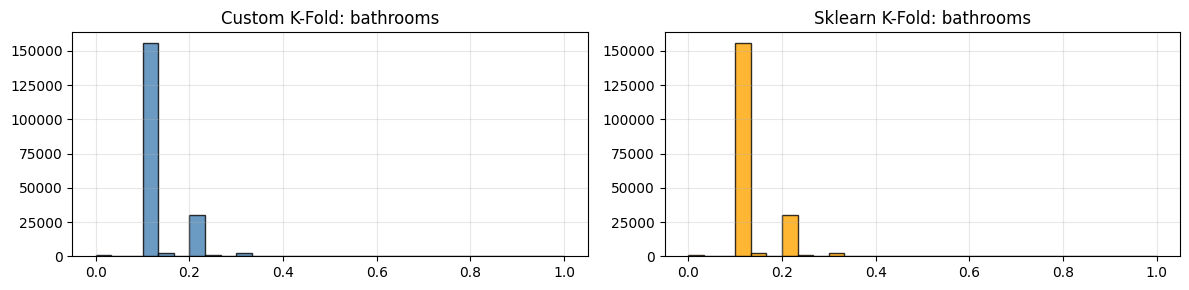

  DogsAllowed: KS=0.0000, p=1.0000 -> идентичны


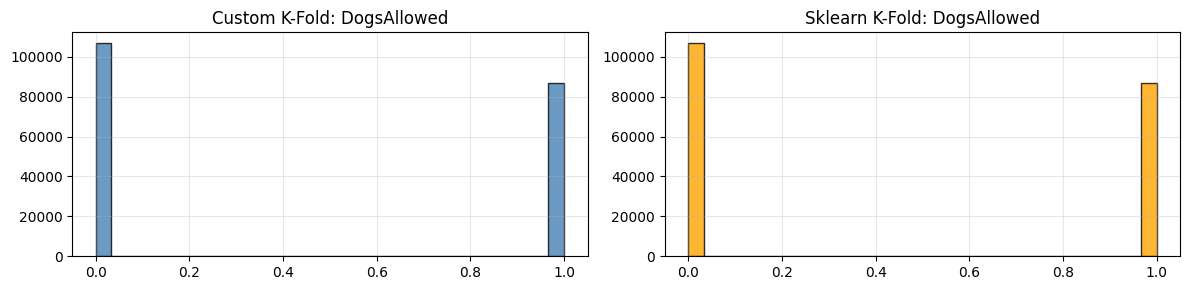

  Elevator: KS=0.0000, p=1.0000 -> идентичны


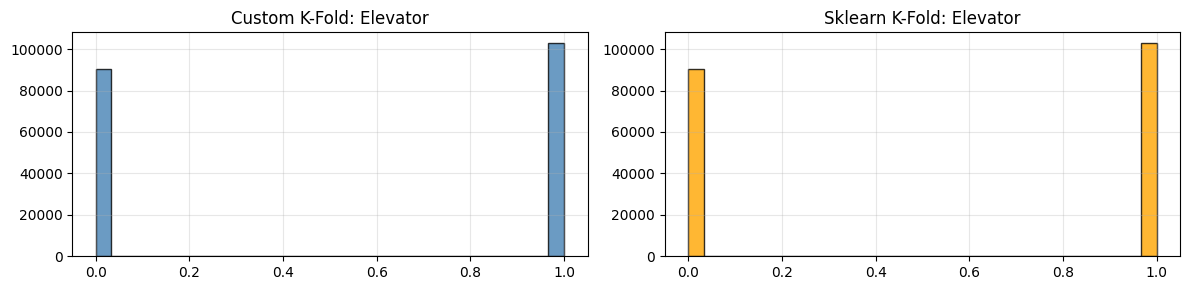

In [31]:
groups = train['manager_id'].values if 'manager_id' in train.columns \
         else np.arange(len(train)) // 100

print("=" * 60)
print("5.1 СРАВНЕНИЕ СХЕМ ВАЛИДАЦИИ")
print("=" * 60)
results_cv = compare_validation_schemes(X_scaled, y, dates_series, groups, feature_list)
for method, m in results_cv.items():
    r2  = m.get('mean_r2', 0)
    std = m.get('std_r2', 0)
    print(f"  {method:<22}: mean R2={r2:.4f} ± {std:.4f}")

print("\n" + "=" * 60)
print("5.2 СРАВНЕНИЕ С SKLEARN")
print("=" * 60)
comp = compare_with_sklearn(X_scaled, y, dates_series, groups, feature_list)
for method, m in comp.items():
    diff = abs(m['custom'] - m['sklearn'])
    print(f"  {method:<22}: Custom R2={m['custom']:.4f}, Sklearn R2={m['sklearn']:.4f}, diff={diff:.4f}")

print("\n" + "=" * 60)
print("5.3 СРАВНЕНИЕ РАСПРЕДЕЛЕНИЙ ПРИЗНАКОВ")
print("=" * 60)
compare_feature_distributions(X_scaled, y, feature_list)

Почему Time Series Split лучше остальных? -> временнАя природа данных (цены на аренду меняются со временем (сезонность, инфляция, спрос))    
Отсутствует утечка данных: модель обучается только на прошлых данных, что соответствует реальному сценарию  
Наивысший R2 (0.5817)

Почему распределения не различаются?    
KS-тесты показали p=1.0000 для всех признаков, потому что:  
Обе реализации (custom и sklearn) используют одинаковый алгоритм K-Fold с random_state=42   
При одинаковом seed перестановка индексов идентична, что подтверждает корректность кастомной реализации.

# 6. Feature Selection

In [ ]:
class FeatureSelector:
    """Реализация методов отбора признаков."""

    def __init__(self, X_train, y_train, X_val, y_val, X_test, y_test, feature_names):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.X_test = X_test
        self.y_test = y_test
        self.feature_names = feature_names

    def _metrics(self, model, X_tr, X_va, X_te, name):
        return {
            'model': name,
            'train_mae': mean_absolute_error(self.y_train, model.predict(X_tr)),
            'valid_mae': mean_absolute_error(self.y_val, model.predict(X_va)),
            'test_mae': mean_absolute_error(self.y_test, model.predict(X_te)),
            'train_rmse': np.sqrt(mean_squared_error(self.y_train, model.predict(X_tr))),
            'valid_rmse': np.sqrt(mean_squared_error(self.y_val, model.predict(X_va))),
            'test_rmse': np.sqrt(mean_squared_error(self.y_test, model.predict(X_te))),
            'train_r2': r2_score(self.y_train, model.predict(X_tr)),
            'valid_r2': r2_score(self.y_val, model.predict(X_va)),
            'test_r2': r2_score(self.y_test, model.predict(X_te)),
        }

    def select_by_lasso(self, alpha: float = 0.01, top_k: int = 10):
        """6.b Lasso coef: обнуляет незначимые, берём top-k ненулевых."""

        lasso = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        lasso.fit(self.X_train, self.y_train)
        coef_abs = np.abs(lasso.coef_)
        top_idx = np.argsort(coef_abs)[::-1][:top_k]
        selected = [self.feature_names[i] for i in top_idx]

        model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        model.fit(self.X_train[:, top_idx], self.y_train)

        return selected, top_idx, model

    def select_by_nan_corr(self, nan_threshold: float = 0.5, corr_threshold: float = 0.9, top_k: int = 10):
        """6.c Фильтр по доле NaN и Pearson-корреляции.
        """
        nan_ratio = np.isnan(self.X_train).mean(axis=0)
        mask_nan = nan_ratio < nan_threshold

        corr_y = np.array([
            np.corrcoef(self.X_train[:, i], self.y_train)[0, 1]
            if not np.all(np.isnan(self.X_train[:, i])) else 0
            for i in range(self.X_train.shape[1])
        ])
        corr_y = np.nan_to_num(corr_y, nan=0)

        corr_matrix = np.nan_to_num(np.corrcoef(self.X_train.T), nan=0)
        keep = np.ones(self.X_train.shape[1], dtype=bool)
        for i in range(self.X_train.shape[1]):
            if not keep[i]: continue
            for j in range(i + 1, self.X_train.shape[1]):
                if keep[j] and abs(corr_matrix[i, j]) > corr_threshold:
                    if abs(corr_y[i]) < abs(corr_y[j]):
                        keep[i] = False
                    else:
                        keep[j] = False

        valid_idx = np.where(mask_nan & keep)[0]
        top_local = np.argsort(np.abs(corr_y[valid_idx]))[::-1][:top_k]
        top_idx = valid_idx[top_local]
        selected = [self.feature_names[i] for i in top_idx]

        model = Lasso(alpha=0.01, random_state=42, max_iter=10000)
        model.fit(self.X_train[:, top_idx], self.y_train)

        return selected, top_idx, model

    def select_by_permutation(self, alpha: float = 0.01, top_k: int = 10, n_repeats: int = 10):
        """6.d Permutation Importance."""

        full_model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        full_model.fit(self.X_train, self.y_train)

        def mae_scorer(est, X, y): return -mean_absolute_error(y, est.predict(X))

        perm = permutation_importance(
            full_model, self.X_val, self.y_val,
            n_repeats=n_repeats, random_state=42, scoring=mae_scorer
        )
        top_idx = np.argsort(perm.importances_mean)[::-1][:top_k]
        selected = [self.feature_names[i] for i in top_idx]

        model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        model.fit(self.X_train[:, top_idx], self.y_train)

        return selected, top_idx, model, perm

    def select_by_shap(self, alpha: float = 0.01, top_k: int = 10):
        """6.e SHAP Values (LinearExplainer для Lasso)."""

        full_model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        full_model.fit(self.X_train, self.y_train)

        explainer = shap.LinearExplainer(full_model, self.X_train)
        shap_vals = explainer.shap_values(self.X_val)
        mean_shap = np.abs(shap_vals).mean(axis=0)

        top_idx = np.argsort(mean_shap)[::-1][:top_k]
        selected = [self.feature_names[i] for i in top_idx]

        model = Lasso(alpha=alpha, random_state=42, max_iter=10000)
        model.fit(self.X_train[:, top_idx], self.y_train)
        
        return selected, top_idx, model, mean_shap

In [ ]:
dates_sorted = dates_series.sort_values()
val_cut = dates_sorted.quantile(0.60)
test_cut = dates_sorted.quantile(0.80)

splitter6 = DataSplitter(random_state=42)

X_raw = train[feature_list].values.astype(float)

d = pd.to_datetime(dates_series)
train_mask6 = d < val_cut
val_mask6 = (d >= val_cut) & (d < test_cut)
test_mask6 = d >= test_cut

X_train_raw = X_raw[train_mask6]
X_val_raw = X_raw[val_mask6]
X_test_raw = X_raw[test_mask6]
y_train6 = y[train_mask6]
y_val6 = y[val_mask6]
y_test6 = y[test_mask6]

mms = MinMaxScaler()
X_train6 = mms.fit_transform(X_train_raw)
X_val6 = mms.transform(X_val_raw)
X_test6 = mms.transform(X_test_raw)

print(f"Датовый сплит 60/20/20:")
print(f"  Train: {len(X_train6)} ({len(X_train6)/len(X)*100:.1f}%)")
print(f"  Val:   {len(X_val6)} ({len(X_val6)/len(X)*100:.1f}%)")
print(f"  Test:  {len(X_test6)} ({len(X_test6)/len(X)*100:.1f}%)")

Датовый сплит 60/20/20:
  Train: 29027 (60.0%)
  Val:   9676 (20.0%)
  Test:  9676 (20.0%)


In [ ]:
selector = FeatureSelector(
    X_train6, y_train6, X_val6, y_val6, X_test6, y_test6, feature_list
)

results_fs = {}

# BASELINE: Lasso на всех признаках (MinMaxScaler)
baseline = Lasso(alpha=0.01, random_state=42, max_iter=10000)
baseline.fit(X_train6, y_train6)
results_fs['Lasso MinMaxScaler'] = selector._metrics(
    baseline, X_train6, X_val6, X_test6, 'Lasso MinMaxScaler')

print("Lasso Feature Importance (все признаки):")
imp_df = pd.DataFrame({
    'ID': range(len(feature_list)), 'Name': feature_list,
    'Importance': np.abs(baseline.coef_)
}).sort_values('Importance', ascending=False).reset_index(drop=True)
print(imp_df.to_string(index=False))

Lasso Feature Importance (все признаки):
 ID              Name   Importance
 20         bathrooms 15530.218440
 21          bedrooms  3218.879866
  4           Doorman   618.135664
 10     LaundryinUnit   488.395425
  8     FitnessCenter   251.723236
 14 HighSpeedInternet   227.027690
  0          Elevator   207.069755
 19           Terrace   204.113964
  3       DogsAllowed   166.544079
  7 LaundryinBuilding   162.114589
  6             NoFee   161.683272
 12      OutdoorSpace   144.082629
 18   NewConstruction   125.950573
 13        DiningRoom   122.822786
  5        Dishwasher   113.288669
 11          RoofDeck   103.667967
  2       CatsAllowed    98.112264
  1    HardwoodFloors    94.877783
 15           Balcony    92.283009
 17 LaundryInBuilding    72.251804
  9           Pre-War    15.887793
 16      SwimmingPool    11.225878


In [ ]:
# 6.b Lasso top-10
t0 = time.time()
sel_lasso, idx_lasso, model_lasso = selector.select_by_lasso(alpha=0.01, top_k=10)
t_lasso = time.time() - t0
print(f"\n6.b Lasso top-10: {sel_lasso}")
results_fs['Lasso top10 MinMaxScaler'] = selector._metrics(
    model_lasso, X_train6[:, idx_lasso], X_val6[:, idx_lasso], X_test6[:, idx_lasso],
    'Lasso top10 MinMaxScaler')


6.b Lasso top-10: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter', 'HighSpeedInternet', 'Elevator', 'Terrace', 'DogsAllowed', 'LaundryinBuilding']


In [ ]:
# 6.c NaN + Correlation filter
t0 = time.time()
sel_nc, idx_nc, model_nc = selector.select_by_nan_corr(top_k=10)
t_nc = time.time() - t0
print(f"6.c NaN+Corr top-10: {sel_nc}")
results_fs['Lasso nan+corr MinMaxScaler'] = selector._metrics(
    model_nc, X_train6[:, idx_nc], X_val6[:, idx_nc], X_test6[:, idx_nc],
    'Lasso nan+corr MinMaxScaler')

6.c NaN+Corr top-10: ['bathrooms', 'bedrooms', 'LaundryinUnit', 'Doorman', 'FitnessCenter', 'Dishwasher', 'DiningRoom', 'Elevator', 'OutdoorSpace', 'NoFee']


In [ ]:
# 6.d Permutation Importance
t0 = time.time()
sel_perm, idx_perm, model_perm, perm_result = selector.select_by_permutation(top_k=10)
t_perm = time.time() - t0
print(f"6.d Permutation top-10: {sel_perm}")
perm_df = pd.DataFrame({
    'Feature': sel_perm,
    'Mean': perm_result.importances_mean[idx_perm],
    'Std': perm_result.importances_std[idx_perm]
})
print(perm_df.to_string(index=False))
results_fs['Lasso permutation MinMaxScaler'] = selector._metrics(
    model_perm, X_train6[:, idx_perm], X_val6[:, idx_perm], X_test6[:, idx_perm],
    'Lasso permutation MinMaxScaler')

6.d Permutation top-10: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'FitnessCenter', 'Elevator', 'DogsAllowed', 'NoFee', 'LaundryinBuilding', 'HighSpeedInternet']
          Feature       Mean      Std
        bathrooms 282.737114 4.643621
         bedrooms 207.537770 4.743920
          Doorman  88.241777 2.650220
    LaundryinUnit  26.653521 1.394323
    FitnessCenter  11.942401 0.969303
         Elevator  10.993500 1.315682
      DogsAllowed   7.804748 0.870247
            NoFee   7.315464 0.804965
LaundryinBuilding   6.094417 0.551335
HighSpeedInternet   4.838583 0.644705


In [ ]:
# 6.e SHAP
t0 = time.time()
sel_shap, idx_shap, model_shap, shap_vals = selector.select_by_shap(top_k=10)
t_shap = time.time() - t0
print(f"\n6.e SHAP top-10: {sel_shap}")
shap_df = pd.DataFrame({'id': idx_shap, 'feature': sel_shap,
                         'shap_value': shap_vals[idx_shap]})
print(shap_df.to_string(index=False))
results_fs['Lasso shap MinMaxScaler'] = selector._metrics(
    model_shap, X_train6[:, idx_shap], X_val6[:, idx_shap], X_test6[:, idx_shap],
    'Lasso shap MinMaxScaler')


6.e SHAP top-10: ['bathrooms', 'bedrooms', 'Doorman', 'LaundryinUnit', 'Elevator', 'FitnessCenter', 'DogsAllowed', 'LaundryinBuilding', 'NoFee', 'Dishwasher']
 id           feature  shap_value
 20         bathrooms  507.187787
 21          bedrooms  421.714513
  4           Doorman  303.995491
 10     LaundryinUnit  146.284424
  0          Elevator  102.851779
  8     FitnessCenter   97.403052
  3       DogsAllowed   82.697845
  7 LaundryinBuilding   76.328226
  6             NoFee   72.244150
  5        Dishwasher   56.463794


In [ ]:
# 6.f Сравнение методов
print("MAE:")
mae_df = pd.DataFrame({
    'model': list(results_fs.keys()),
    'train': [m['train_mae'] for m in results_fs.values()],
    'valid': [m['valid_mae'] for m in results_fs.values()],
    'test': [m['test_mae']  for m in results_fs.values()],
})
print(mae_df.to_string(index=False))

print("\nRMSE:")
rmse_df = pd.DataFrame({
    'model': list(results_fs.keys()),
    'train': [m['train_rmse'] for m in results_fs.values()],
    'valid': [m['valid_rmse'] for m in results_fs.values()],
    'test': [m['test_rmse']  for m in results_fs.values()],
})
print(rmse_df.to_string(index=False))

print("\nR2:")
r2_df = pd.DataFrame({
    'model': list(results_fs.keys()),
    'train': [m['train_r2'] for m in results_fs.values()],
    'valid': [m['valid_r2'] for m in results_fs.values()],
    'test': [m['test_r2']  for m in results_fs.values()],
})
print(r2_df.to_string(index=False))

print(f"""
Сравнение методов:
  СКОРОСТЬ: {t_lasso:.2f}s (Lasso) < {t_nc:.2f}s (NaN+Corr) < {t_perm:.2f}s (Perm) < {t_shap:.2f}s (SHAP)
""")

MAE:
                         model      train      valid       test
            Lasso MinMaxScaler 704.872851 721.287856 724.302388
      Lasso top10 MinMaxScaler 707.357929 726.124691 727.828894
   Lasso nan+corr MinMaxScaler 715.108468 732.840506 736.741712
Lasso permutation MinMaxScaler 706.769600 724.006458 727.895449
       Lasso shap MinMaxScaler 709.686630 726.555451 728.123543

RMSE:
                         model       train       valid        test
            Lasso MinMaxScaler 1031.778021 1049.086613 1043.316796
      Lasso top10 MinMaxScaler 1037.641282 1056.826703 1049.416714
   Lasso nan+corr MinMaxScaler 1043.462907 1062.403526 1054.922475
Lasso permutation MinMaxScaler 1035.506028 1053.241277 1047.074167
       Lasso shap MinMaxScaler 1037.926173 1055.661002 1047.756279

R²:
                         model    train    valid     test
            Lasso MinMaxScaler 0.577134 0.587808 0.570876
      Lasso top10 MinMaxScaler 0.572315 0.581703 0.565844
   Lasso nan+corr MinMa

# 7. Оптимизация гиперпараметров

In [ ]:
class HyperparameterOptimizer:
    """Grid Search, Random Search и Bayesian (Optuna) для ElasticNet."""

    def __init__(
        self,
        X_train: np.ndarray, y_train: np.ndarray,
        X_val: np.ndarray, y_val: np.ndarray,
        param_grid: dict
    ):
        self.X_train = X_train
        self.y_train = y_train
        self.X_val = X_val
        self.y_val = y_val
        self.param_grid = param_grid

    def grid_search(self) -> dict:
        """7.1 Grid Search: перебирает все комбинации сетки.
        """
        best_mae, best_params = float('inf'), {}
        for params in ParameterGrid(self.param_grid):
            model = ElasticNet(**params, random_state=42, max_iter=10000)
            model.fit(self.X_train, self.y_train)
            mae = mean_absolute_error(self.y_val, model.predict(self.X_val))
            if mae < best_mae:
                best_mae, best_params = mae, params

        return {'best_params': best_params, 'best_val_mae': best_mae}

    def random_search(self, n_iter: int = 20) -> dict:
        """7.1 Random Search: случайно семплирует n_iter комбинаций.
        """
        best_mae, best_params = float('inf'), {}
        for params in ParameterSampler(self.param_grid, n_iter=n_iter, random_state=42):
            model = ElasticNet(**params, random_state=42, max_iter=10000)
            model.fit(self.X_train, self.y_train)
            mae = mean_absolute_error(self.y_val, model.predict(self.X_val))  # ← val!
            if mae < best_mae:
                best_mae, best_params = mae, params

        return {'best_params': best_params, 'best_val_mae': best_mae}

    def bayesian_optuna(
        self,
        n_trials: int = 50,
        use_cv: bool = False
    ) -> dict:
        """7.4 Bayesian Optimization через Optuna (TPE sampler).
        
        use_cv=False -> оцениваем на val-выборке (быстро).
        use_cv=True  -> K-Fold на train+val (стабильнее, медленнее).
        """
        X_combined = np.vstack([self.X_train, self.X_val])
        y_combined = np.hstack([self.y_train, self.y_val])

        def objective(trial):
            alpha = trial.suggest_float('alpha', 1e-4, 200.0, log=True)
            l1_ratio = trial.suggest_float('l1_ratio', 0.0, 1.0)
            model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio,
                               random_state=42, max_iter=10000)
            if use_cv:
                scores = cross_val_score(
                    model, X_combined, y_combined, cv=5,
                    scoring='neg_mean_absolute_error'
                )

                return -scores.mean()
            
            else:
                model.fit(self.X_train, self.y_train)

                return mean_absolute_error(self.y_val, model.predict(self.X_val))

        study = optuna.create_study(
            direction='minimize',
            sampler=optuna.samplers.TPESampler(seed=42)
        )
        study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
        return {'best_params': study.best_params, 'best_val_mae': study.best_value, 'study': study}

In [ ]:
# Данные для оптимизации — те же датовые сплиты из Task 6
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0],
    'l1_ratio': [0.0, 0.25, 0.5, 0.75, 1.0]
}

optimizer = HyperparameterOptimizer(
    X_train6, y_train6, X_val6, y_val6, param_grid
)

# 7.1-7.2 Grid Search
print("Grid Search (40 комбинаций):")
t0 = time.time()
gs = optimizer.grid_search()
t_gs = time.time() - t0
print(f"  Лучшие параметры: {gs['best_params']}")
print(f"  Val MAE: {gs['best_val_mae']:.2f} | Время: {t_gs:.2f}s")

# Random Search
print("\nRandom Search (n_iter=20):")
t0 = time.time()
rs = optimizer.random_search(n_iter=20)
t_rs = time.time() - t0
print(f"  Лучшие параметры: {rs['best_params']}")
print(f"  Val MAE: {rs['best_val_mae']:.2f} | Время: {t_rs:.2f}s")

# 7.3 Финальная модель Grid Search
print("\n7.3 Финальная модель (Grid Search best):")
final_gs = ElasticNet(**gs['best_params'], random_state=42, max_iter=10000)
final_gs.fit(X_train6, y_train6)
for name, Xp, yp in [('train', X_train6, y_train6), ('valid', X_val6, y_val6), ('test', X_test6, y_test6)]:
    p = final_gs.predict(Xp)
    print(f"  {name}: MAE={mean_absolute_error(yp,p):.2f}, "
          f"RMSE={np.sqrt(mean_squared_error(yp,p)):.2f}, R²={r2_score(yp,p):.4f}")

# 7.4-7.5 Optuna (на val)
print("\n7.4 Optuna (50 trials, без CV):")
t0 = time.time()
opt = optimizer.bayesian_optuna(n_trials=50, use_cv=False)
t_opt = time.time() - t0
print(f"  Лучшие параметры: {opt['best_params']}")
print(f"  Val MAE: {opt['best_val_mae']:.2f} | Время: {t_opt:.2f}s")

final_opt = ElasticNet(**opt['best_params'], random_state=42, max_iter=10000)
final_opt.fit(X_train6, y_train6)
print("  Метрики:")

for name, Xp, yp in [('train', X_train6, y_train6), ('valid', X_val6, y_val6), ('test', X_test6, y_test6)]:
    p = final_opt.predict(Xp)
    print(f"    {name}: MAE={mean_absolute_error(yp,p):.2f}, "
          f"RMSE={np.sqrt(mean_squared_error(yp,p)):.2f}, R²={r2_score(yp,p):.4f}")

# 7.6 Optuna + KFold CV
print("\n7.6 Optuna + K-Fold CV (30 trials):")
t0 = time.time()
opt_cv = optimizer.bayesian_optuna(n_trials=30, use_cv=True)
t_cv = time.time() - t0
print(f"  Лучшие параметры: {opt_cv['best_params']}")
print(f"  CV MAE: {opt_cv['best_val_mae']:.2f} | Время: {t_cv:.2f}s")

# Итоговое сравнение
print("\n" + "="*65)
print("ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ ОПТИМИЗАЦИИ")
print("="*65)
cmp_df = pd.DataFrame({
    'Method': ['Grid Search', 'Random Search', 'Optuna (val)', 'Optuna (CV)'],
    'Iterations': [len(list(ParameterGrid(param_grid))), 20, 50, 30],
    'Time (s)': [round(t_gs,2), round(t_rs,2), round(t_opt,2), round(t_cv,2)],
    'Best Val MAE':[round(gs['best_val_mae'],2), round(rs['best_val_mae'],2),
                       round(opt['best_val_mae'],2), round(opt_cv['best_val_mae'],2)],
    'Best alpha': [gs['best_params']['alpha'], rs['best_params']['alpha'],
                       round(opt['best_params']['alpha'],4), round(opt_cv['best_params']['alpha'],4)],
    'Best l1_ratio': [gs['best_params']['l1_ratio'], rs['best_params']['l1_ratio'],
                       round(opt['best_params']['l1_ratio'],4), round(opt_cv['best_params']['l1_ratio'],4)],
})
print(cmp_df.to_string(index=False))

Grid Search (40 комбинаций):
  Лучшие параметры: {'alpha': 0.5, 'l1_ratio': 1.0}
  Val MAE: 721.14 | Время: 233.82s

Random Search (n_iter=20):
  Лучшие параметры: {'l1_ratio': 1.0, 'alpha': 0.5}
  Val MAE: 721.14 | Время: 105.50s

7.3 Финальная модель (Grid Search best):
  train: MAE=704.66, RMSE=1031.88, R²=0.5771
  valid: MAE=721.14, RMSE=1049.57, R²=0.5874
  test: MAE=724.35, RMSE=1043.64, R²=0.5706

7.4 Optuna (50 trials, без CV):
  Лучшие параметры: {'alpha': 0.0001348042287380526, 'l1_ratio': 0.9699098521619943}
  Val MAE: 721.30 | Время: 1697.20s
  Метрики:
    train: MAE=704.89, RMSE=1031.78, R²=0.5771
    valid: MAE=721.30, RMSE=1049.13, R²=0.5878
    test: MAE=724.34, RMSE=1043.36, R²=0.5708

7.6 Optuna + K-Fold CV (30 trials):
  Лучшие параметры: {'alpha': 0.0001348042287380526, 'l1_ratio': 0.9699098521619943}
  CV MAE: 711.09 | Время: 4195.96s

ИТОГОВОЕ СРАВНЕНИЕ МЕТОДОВ ОПТИМИЗАЦИИ
       Method  Iterations  Time (s)  Best Val MAE  Best alpha  Best l1_ratio
  Grid Search 

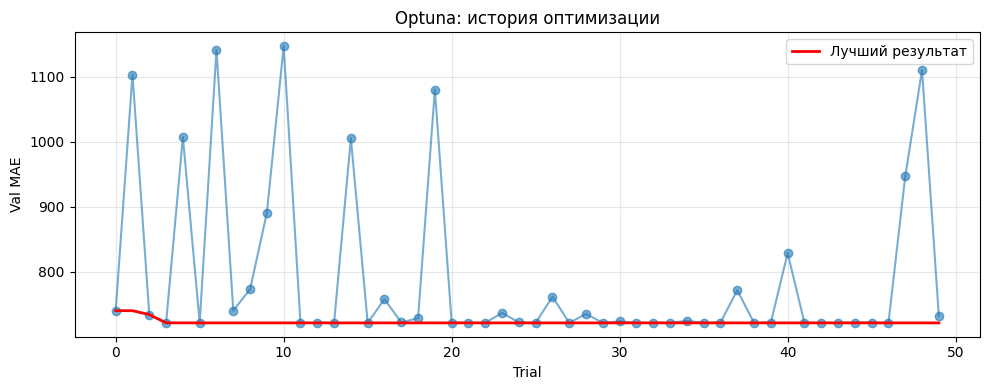

In [27]:
# График истории Optuna
if 'study' in opt:
    trials = opt['study'].trials
    plt.figure(figsize=(10, 4))
    plt.plot([t.number for t in trials], [t.value for t in trials], 'o-', alpha=0.6)
    best_so_far = pd.Series([t.value for t in trials]).cummin()
    plt.plot([t.number for t in trials], best_so_far, 'r-', lw=2, label='Лучший результат')
    plt.xlabel('Trial'); plt.ylabel('Val MAE'); plt.title('Optuna: история оптимизации')
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()